# Etapes 3 & 4 - Modelisation avec tracking MLflow

Version MLflow de `modeling_local.ipynb` — memes modeles et metriques, chaque run est trace dans MLflow.

**Etape 3** : baseline Dummy, LogReg, LightGBM.

**Etape 4** : optimisation GridSearch / RandomizedSearch + runs finaux loggues.

Metriques OOF au seuil optimal minimisant `10 x FN + FP`.

In [1]:
import os, sys, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import mlflow
import mlflow.sklearn
import mlflow.lightgbm

from sklearn.model_selection import (
    StratifiedKFold, RandomizedSearchCV, GridSearchCV, train_test_split,
)
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    f1_score, recall_score, precision_score, confusion_matrix,
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import lightgbm as lgb
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

from src.config import (
    RANDOM_STATE, N_FOLDS, TEST_SIZE, TARGET_COL, ID_COL,
    PROCESSED_DIR, MODELS_DIR, FIGURES_DIR, LGB_DEVICE,
    MLFLOW_TRACKING_URI, MLFLOW_EXPERIMENT_NAME,
)

print(f'Device  : {LGB_DEVICE}')
print(f'N_FOLDS : {N_FOLDS}  |  RANDOM_STATE : {RANDOM_STATE}')


2026-05-30 07:50:18 | INFO     | src.config - LightGBM device : gpu


Device  : gpu
N_FOLDS : 5  |  RANDOM_STATE : 42


## 0. Configuration MLflow

In [2]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

print(f'Tracking URI : {MLFLOW_TRACKING_URI}')
print(f'Experiment   : {MLFLOW_EXPERIMENT_NAME}')


Tracking URI : sqlite:///C:\Users\fkhellad\Formation_IA\Projet6_mission\mlflow.db
Experiment   : home_credit_scoring


## 1. Chargement des donnees

In [3]:
train_df = pd.read_csv(PROCESSED_DIR / 'train_processed_global.csv')
print(f'Shape  : {train_df.shape}')
print(f'Defaut : {train_df[TARGET_COL].mean():.2%}')


Shape  : (307507, 554)
Defaut : 8.07%


In [4]:
COLS_EXCLUDE = [TARGET_COL, ID_COL, 'SK_ID_BUREAU', 'SK_ID_PREV', 'index']
features = [c for c in train_df.columns if c not in COLS_EXCLUDE]

X = train_df[features].copy()
y = train_df[TARGET_COL].copy()

# Nettoyage des noms de colonnes — LightGBM rejette les caracteres speciaux
X.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', c) for c in X.columns]

print(f'X : {X.shape}  |  Classes : {y.value_counts().to_dict()}')


X : (307507, 552)  |  Classes : {0: 282682, 1: 24825}


## 1.1 Split train / test stratifie

Separation **unique** avant tout entrainement. `X_test` et `y_test` ne servent qu'a l'evaluation finale non biaisee — jamais utilises pendant la CV ni le reglage des hyperparametres.

In [5]:
# Split unique : ratio TEST_SIZE defini dans src/config.py
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')
print(f'Taux defaut  train : {y_train.mean():.2%}  |  test : {y_test.mean():.2%}')

# Tags MLflow communs a tous les runs — documentent la methodologie
_SPLIT_TAGS = {
    'split_type': 'stratified',
    'test_size':  str(TEST_SIZE),
    'n_train':    str(len(X_train)),
    'n_test':     str(len(X_test)),
}


Train : (246005, 552)  |  Test : (61502, 552)
Taux defaut  train : 8.07%  |  test : 8.07%


## 2. Fonctions utilitaires

In [6]:
def compute_business_cost(y_true, y_pred, fn_cost=10, fp_cost=1):
    """Cout metier asymetrique : fn_cost * FN + fp_cost * FP.

    Un defaillant manque (FN) coute 10x plus qu'un bon client refuse (FP).
    Retourne (cout_total, nb_fn, nb_fp).
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()  # ordre sklearn : TN FP FN TP
    return fn_cost * fn + fp_cost * fp, int(fn), int(fp)


def find_best_threshold(y_true, y_proba, thresholds=None):
    """Cherche le seuil de decision qui minimise le cout metier.

    Parcourt les seuils de 0.01 a 0.98 par pas de 0.01.
    Retourne (seuil_optimal: float, cout_minimal: int).
    """
    if thresholds is None:
        thresholds = np.arange(0.01, 0.99, 0.01)
    best_t, best_c = 0.5, float('inf')  # valeurs initiales : seuil neutre, cout infini
    for t in thresholds:
        c, _, _ = compute_business_cost(y_true, (y_proba >= t).astype(int))
        if c < best_c:  # mise a jour si ce seuil donne un cout plus faible
            best_c, best_t = c, t
    return round(float(best_t), 2), int(best_c)


def compute_all_metrics(name, y_true, y_proba, fold_aucs):
    """Consolide toutes les metriques a partir des predictions OOF.

    Calcule AUC, PR-AUC, Recall, Precision, F1 et cout metier au seuil optimal.
    Retourne un dict directement utilisable dans pd.DataFrame.
    """
    thresh, cost = find_best_threshold(y_true, y_proba)      # seuil qui minimise le cout metier
    y_pred = (y_proba >= thresh).astype(int)                  # binarisation au seuil optimal
    _, fn, fp = compute_business_cost(y_true, y_pred)         # recalcul pour isoler FN et FP
    return {
        'Modele':      name,
        'AUC moy':     round(float(np.mean(fold_aucs)), 4),
        'AUC std':     round(float(np.std(fold_aucs)),  4),
        'PR-AUC':      round(float(average_precision_score(y_true, y_proba)), 4),
        'Recall':      round(float(recall_score(y_true, y_pred)),   4),
        'Precision':   round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
        'F1':          round(float(f1_score(y_true, y_pred)),       4),
        'Seuil':       thresh,
        'Cout metier': cost,
        'FN':          fn,
        'FP':          fp,
    }

print('Metriques chargees.')


Metriques chargees.


In [7]:
def plot_roc_curves(models_probas, y_true, title='Courbes ROC'):
    """Trace les courbes ROC de plusieurs modeles sur le meme graphique.

    models_probas : dict {nom_modele: array de probabilites de la classe positive}
    Retourne la figure matplotlib pour le logging MLflow.
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    for name, proba in models_probas.items():
        fpr, tpr, _ = roc_curve(y_true, proba)  # taux de faux positifs et vrais positifs
        auc = roc_auc_score(y_true, proba)
        ax.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.4f})')
    ax.plot([0, 1], [0, 1], '--', color='gray', label='Aleatoire (AUC = 0.5)')  # diagonale : classifieur aleatoire
    ax.set_xlabel('Taux Faux Positifs (FPR)')
    ax.set_ylabel('Taux Vrais Positifs (TPR)')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True)
    fig.tight_layout()
    plt.show()
    return fig


def plot_threshold_curve(y_true, y_proba, model_name=''):
    """Trace le cout metier en fonction du seuil de decision.

    Marque le seuil optimal (minimum du cout) d'une ligne verticale rouge.
    Retourne la figure matplotlib pour le logging MLflow.
    """
    thresholds = np.arange(0.01, 0.99, 0.01)
    costs = [
        compute_business_cost(y_true, (y_proba >= t).astype(int))[0]  # cout pour chaque seuil
        for t in thresholds
    ]
    best_t, best_c = find_best_threshold(y_true, y_proba)  # seuil optimal sur cette courbe
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(thresholds, costs, linewidth=2)
    ax.axvline(
        best_t, linestyle='--', color='red',
        label=f'Seuil optimal = {best_t:.2f}  ->  cout = {best_c:,}'
    )
    ax.set_xlabel('Seuil de decision')
    ax.set_ylabel('Cout metier  (10 x FN + FP)')
    ax.set_title(f'Cout metier vs Seuil - {model_name}')
    ax.legend()
    ax.grid(True)
    fig.tight_layout()
    plt.show()
    return fig


def display_results(df, title=''):
    """Affiche le tableau de metriques avec mise en forme coloree.

    Met en vert les meilleures valeurs (AUC, Recall, F1)
    et les couts les plus bas (Cout metier, FN, FP).
    """
    if title:
        print(f"{'='*60}\n  {title}\n{'='*60}")
    styled = (
        df.style
        .highlight_max(subset=['AUC moy', 'PR-AUC', 'Recall', 'F1'], color='#c6efce')  # vert : valeurs les plus hautes
        .highlight_min(subset=['Cout metier', 'FN', 'FP'], color='#c6efce')             # vert : valeurs les plus basses
        .format({
            'AUC moy':   '{:.4f}',
            'AUC std':   '{:.4f}',
            'PR-AUC':    '{:.4f}',
            'Recall':    '{:.4f}',
            'Precision': '{:.4f}',
            'F1':        '{:.4f}',
        })
    )
    display(styled)

print('Visualisation chargee.')


Visualisation chargee.


In [8]:
def log_metrics_mlflow(metrics: dict):
    """Enregistre les metriques OOF dans le run MLflow actif.

    metrics : dict retourne par compute_all_metrics().
    Doit etre appele a l'interieur d'un bloc mlflow.start_run().
    """
    # Noms de cles normalises : minuscules, sans accents ni espaces (convention MLflow)
    mlflow.log_metrics({
        'auc_mean':    metrics['AUC moy'],     # moyenne des AUC par fold
        'auc_std':     metrics['AUC std'],     # ecart-type : mesure la stabilite entre folds
        'pr_auc':      metrics['PR-AUC'],      # aire sous la courbe Precision-Recall
        'recall':      metrics['Recall'],      # taux de detection des defaillants
        'precision':   metrics['Precision'],
        'f1':          metrics['F1'],
        'seuil':       float(metrics['Seuil']),
        'cout_metier': float(metrics['Cout metier']),
        'fn':          float(metrics['FN']),   # defaillants manques (erreur la plus couteuse)
        'fp':          float(metrics['FP']),   # bons clients refuses
    })

print('Helper MLflow charge.')


Helper MLflow charge.


## 3. Fonctions de validation croisee

In [9]:
def cv_sklearn(name, make_model, X, y, needs_scaling=False, verbose=True):
    """Validation croisee StratifiedKFold pour les modeles scikit-learn.

    make_model  : callable sans argument retournant un estimateur frais a chaque fold.
    needs_scaling : si True, applique SimpleImputer + StandardScaler dans chaque fold
                    (fit uniquement sur les donnees d'entrainement du fold).
    Retourne (metriques: dict, oof_proba: np.ndarray).
    """
    skf  = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    oof  = np.zeros(len(y))  # contiendra les probabilites predites sur les folds de validation
    aucs = []                # AUC de chaque fold, pour calculer moyenne et ecart-type

    for fold, (tr, val) in enumerate(skf.split(X, y), 1):
        X_tr, X_val = X.values[tr], X.values[val]
        y_tr, y_val = y.values[tr], y.values[val]

        if needs_scaling:
            # Imputation et standardisation fitees sur X_tr uniquement — evite la fuite de donnees
            imp   = SimpleImputer(strategy='median')
            X_tr  = imp.fit_transform(X_tr)
            X_val = imp.transform(X_val)
            sc    = StandardScaler()
            X_tr  = sc.fit_transform(X_tr)
            X_val = sc.transform(X_val)

        model = make_model()  # nouvel estimateur a chaque fold pour eviter toute fuite
        model.fit(X_tr, y_tr)
        oof[val] = model.predict_proba(X_val)[:, 1]  # probabilite classe positive (defaut)

        auc = roc_auc_score(y_val, oof[val])
        aucs.append(auc)
        if verbose:
            print(f'  Fold {fold}/{N_FOLDS}  AUC = {auc:.4f}')

    metrics = compute_all_metrics(name, y, oof, aucs)
    print(f"  -> OOF AUC = {metrics['AUC moy']:.4f} +/- {metrics['AUC std']:.4f}")
    return metrics, oof


def cv_lgbm(name, params, X, y, verbose=True):
    """Validation croisee StratifiedKFold pour LightGBM avec early stopping.

    L'early stopping arrete l'entrainement apres 100 rounds sans amelioration
    de l'AUC sur le fold de validation, evitant le sur-apprentissage.
    Retourne (metriques: dict, oof_proba: np.ndarray).
    """
    skf  = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    oof  = np.zeros(len(y))  # contiendra les probabilites predites sur les folds de validation
    aucs = []                # AUC de chaque fold

    for fold, (tr, val) in enumerate(skf.split(X, y), 1):
        X_tr, X_val = X.iloc[tr], X.iloc[val]
        y_tr, y_val = y.iloc[tr], y.iloc[val]

        model = LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],  # jeu de validation pour surveiller la convergence
            eval_metric='auc',
            callbacks=[
                lgb.early_stopping(stopping_rounds=100, verbose=False),  # arrete si pas de progres sur 100 rounds
                lgb.log_evaluation(period=-1),  # desactive les logs LightGBM internes
            ],
        )
        oof[val] = model.predict_proba(X_val)[:, 1]  # probabilite classe positive (defaut)
        auc      = roc_auc_score(y_val, oof[val])
        aucs.append(auc)
        if verbose:
            print(f'  Fold {fold}/{N_FOLDS}  AUC = {auc:.4f}  '
                  f'(meilleure iteration = {model.best_iteration_})')

    metrics = compute_all_metrics(name, y, oof, aucs)
    print(f"  -> OOF AUC = {metrics['AUC moy']:.4f} +/- {metrics['AUC std']:.4f}")
    return metrics, oof

print('Fonctions CV chargees.')


Fonctions CV chargees.


---
## Etape 3 - Comparaison des modeles baseline

Chaque modele est trace dans un run MLflow distinct. Tag `etape=3`, `model_type=baseline`.

### Modele 1 : Dummy Classifier

In [10]:
with mlflow.start_run(run_name='Dummy_baseline'):
    mlflow.set_tag('model_type', 'baseline')
    mlflow.set_tags(_SPLIT_TAGS)

    print('=== Dummy Classifier ===')
    dummy_metrics, dummy_proba = cv_sklearn(
        'Dummy',
        lambda: DummyClassifier(strategy='prior', random_state=RANDOM_STATE),
        X_train, y_train,
    )
    log_metrics_mlflow(dummy_metrics)
    print('Run MLflow : Dummy_baseline enregistre.')


=== Dummy Classifier ===
  Fold 1/5  AUC = 0.5000
  Fold 2/5  AUC = 0.5000
  Fold 3/5  AUC = 0.5000
  Fold 4/5  AUC = 0.5000
  Fold 5/5  AUC = 0.5000
  -> OOF AUC = 0.5000 +/- 0.0000
Run MLflow : Dummy_baseline enregistre.


### Modele 2 : Logistic Regression baseline

In [11]:
LR_BASELINE_PARAMS = {
    'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs',
    'class_weight': 'balanced', 'max_iter': 1000,
}

with mlflow.start_run(run_name='LR_baseline'):
    mlflow.set_tag('model_type', 'baseline')
    mlflow.set_tags(_SPLIT_TAGS)
    mlflow.log_params({'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'})

    print('=== Logistic Regression baseline ===')
    logreg_metrics, logreg_proba = cv_sklearn(
        'Logistic Regression',
        lambda: LogisticRegression(**LR_BASELINE_PARAMS, random_state=RANDOM_STATE, n_jobs=1),
        X_train, y_train, needs_scaling=True,
    )
    log_metrics_mlflow(logreg_metrics)
    print('Run MLflow : LR_baseline enregistre.')


=== Logistic Regression baseline ===
  Fold 1/5  AUC = 0.7737
  Fold 2/5  AUC = 0.7678
  Fold 3/5  AUC = 0.7731
  Fold 4/5  AUC = 0.7740
  Fold 5/5  AUC = 0.7735
  -> OOF AUC = 0.7724 +/- 0.0023
Run MLflow : LR_baseline enregistre.


### Modele 3 : LightGBM baseline

In [12]:
LGBM_BASE_PARAMS = {
    'n_estimators':      1000,
    'learning_rate':     0.05,
    'num_leaves':        31,
    'max_depth':         -1,
    'min_child_samples': 20,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'reg_alpha':         0.0,
    'reg_lambda':        0.0,
    'objective':         'binary',
    'class_weight':      'balanced',
    'random_state':      RANDOM_STATE,
    'n_jobs':            1,
    'verbosity':         -1,
    'device':            LGB_DEVICE,
}

with mlflow.start_run(run_name='LightGBM_baseline'):
    mlflow.set_tag('model_type', 'baseline')
    mlflow.set_tags(_SPLIT_TAGS)
    # Exclusion des parametres techniques non pertinents pour le tracking
    _exclude = ('n_jobs', 'verbosity', 'objective', 'random_state')
    mlflow.log_params({k: v for k, v in LGBM_BASE_PARAMS.items() if k not in _exclude})

    print('=== LightGBM baseline ===')
    lgbm_metrics, lgbm_proba = cv_lgbm('LightGBM baseline', LGBM_BASE_PARAMS, X_train, y_train)
    log_metrics_mlflow(lgbm_metrics)
    print('Run MLflow : LightGBM_baseline enregistre.')


=== LightGBM baseline ===
  Fold 1/5  AUC = 0.7855  (meilleure iteration = 301)
  Fold 2/5  AUC = 0.7843  (meilleure iteration = 220)
  Fold 3/5  AUC = 0.7860  (meilleure iteration = 377)
  Fold 4/5  AUC = 0.7875  (meilleure iteration = 236)
  Fold 5/5  AUC = 0.7861  (meilleure iteration = 228)
  -> OOF AUC = 0.7859 +/- 0.0010
Run MLflow : LightGBM_baseline enregistre.


### Resultats Etape 3

  Etape 3 - Comparaison des modeles


,AUC moy,AUC std,PR-AUC,Recall,Precision,F1,Seuil,Cout metier,FN,FP
Modele,,,,,,,,,,
Dummy,0.5000,0.0000,0.0807,0.0000,0.0000,0.0000,0.090000,198600,19860,0
Logistic Regression,0.7724,0.0023,0.2488,0.6883,0.1777,0.2825,0.510000,125151,6191,63241
LightGBM baseline,0.7859,0.0010,0.2746,0.6899,0.1882,0.2958,0.490000,120670,6159,59080


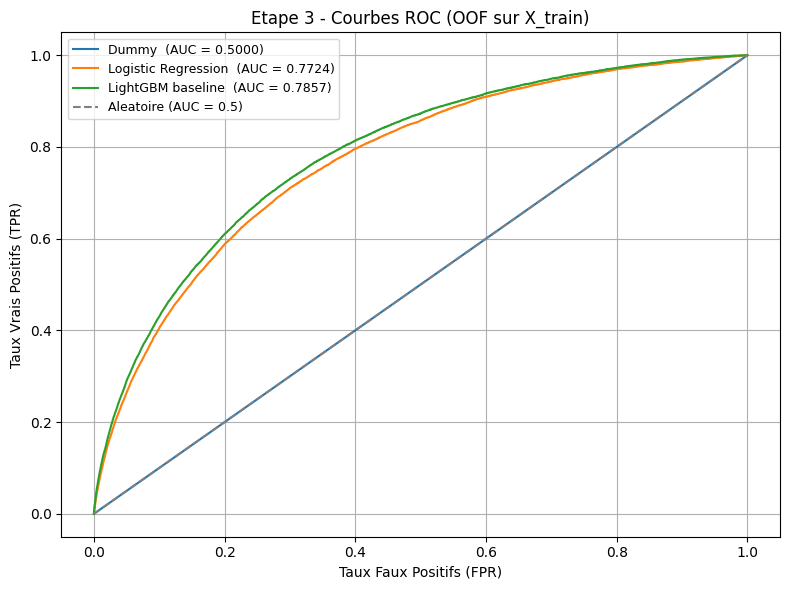

Figure sauvegardee : roc_step3.png


In [13]:
results_step3 = pd.DataFrame(
    [dummy_metrics, logreg_metrics, lgbm_metrics]
).set_index('Modele')

display_results(results_step3, 'Etape 3 - Comparaison des modeles')

fig_roc3 = plot_roc_curves(
    {
        'Dummy':               dummy_proba,
        'Logistic Regression': logreg_proba,
        'LightGBM baseline':   lgbm_proba,
    },
    y_train, title='Etape 3 - Courbes ROC (OOF sur X_train)',
)
fig_roc3.savefig(FIGURES_DIR / 'roc_step3.png', dpi=150, bbox_inches='tight')
plt.close(fig_roc3)
print('Figure sauvegardee : roc_step3.png')


---
## Etape 4 - Optimisation des hyperparametres

- **Logistic Regression** -> `GridSearchCV` sur 20% du dataset
- **LightGBM** -> `RandomizedSearchCV` (30 combinaisons) puis `GridSearchCV` (fine-tuning)

Les runs MLflow sont crees uniquement pour les CV finales (section 4.4).

### 4.1 Logistic Regression - GridSearchCV

In [14]:
X_srch, _, y_srch, _ = train_test_split(
    X_train, y_train, train_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)
print(f'Taille du sous-echantillon : {X_srch.shape}')

lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('lr',      LogisticRegression(
        max_iter=1000, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=1,
    )),
])

param_grid_lr = {
    'lr__C':       [0.001, 0.01, 0.1],
    'lr__penalty': ['l2'],
    'lr__solver':  ['liblinear'],
}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

gs_lr = GridSearchCV(
    lr_pipeline, param_grid_lr,
    cv=skf, scoring='roc_auc',
    n_jobs=1, verbose=2,
)
gs_lr.fit(X_srch, y_srch)

print(f'\nMeilleurs params : {gs_lr.best_params_}')
print(f'Meilleur AUC CV  : {gs_lr.best_score_:.4f}')

best_lr_params = {k.replace('lr__', ''): v for k, v in gs_lr.best_params_.items()}
print(f'Params nets      : {best_lr_params}')


Taille du sous-echantillon : (49201, 552)
Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END ..lr__C=0.001, lr__penalty=l2, lr__solver=liblinear; total time=   5.2s
[CV] END ..lr__C=0.001, lr__penalty=l2, lr__solver=liblinear; total time=   5.1s
[CV] END ..lr__C=0.001, lr__penalty=l2, lr__solver=liblinear; total time=   5.1s
[CV] END ..lr__C=0.001, lr__penalty=l2, lr__solver=liblinear; total time=   5.4s
[CV] END ..lr__C=0.001, lr__penalty=l2, lr__solver=liblinear; total time=   5.2s
[CV] END ...lr__C=0.01, lr__penalty=l2, lr__solver=liblinear; total time=   9.9s
[CV] END ...lr__C=0.01, lr__penalty=l2, lr__solver=liblinear; total time=   9.4s
[CV] END ...lr__C=0.01, lr__penalty=l2, lr__solver=liblinear; total time=   8.6s
[CV] END ...lr__C=0.01, lr__penalty=l2, lr__solver=liblinear; total time=  10.4s
[CV] END ...lr__C=0.01, lr__penalty=l2, lr__solver=liblinear; total time=   9.4s
[CV] END ....lr__C=0.1, lr__penalty=l2, lr__solver=liblinear; total time=  25.0s
[CV] EN

### 4.2 LightGBM - RandomizedSearchCV

In [16]:
lgb_param_dist = {
    'n_estimators':      [300, 500],
    'learning_rate':     [0.05, 0.1],
    'num_leaves':        [31, 63, 100],
    'min_child_samples': [20, 50, 100, 150],
    'subsample':         [0.6, 0.8, 1.0],
    'colsample_bytree':  [0.6, 0.8, 1.0],
    'reg_lambda':        [0, 0.1, 1.0],
    'class_weight':      ['balanced'],
}

lgb_for_search = LGBMClassifier(
    objective='binary', max_depth=-1,
    random_state=RANDOM_STATE,
    n_jobs=1, verbosity=-1, device=LGB_DEVICE,
)

random_lgb = RandomizedSearchCV(
    lgb_for_search, lgb_param_dist,
    n_iter=30, cv=skf, scoring='roc_auc',
    random_state=RANDOM_STATE, n_jobs=1, verbose=2,
)
random_lgb.fit(X_train, y_train)

print(f'\nMeilleur AUC RandomizedSearch : {random_lgb.best_score_:.4f}')
print(f'Meilleurs params              : {random_lgb.best_params_}')


Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END class_weight=balanced, colsample_bytree=0.8, learning_rate=0.05, min_child_samples=150, n_estimators=300, num_leaves=31, reg_lambda=0.1, subsample=0.8; total time=  22.0s
[CV] END class_weight=balanced, colsample_bytree=0.8, learning_rate=0.05, min_child_samples=150, n_estimators=300, num_leaves=31, reg_lambda=0.1, subsample=0.8; total time=  22.5s
[CV] END class_weight=balanced, colsample_bytree=0.8, learning_rate=0.05, min_child_samples=150, n_estimators=300, num_leaves=31, reg_lambda=0.1, subsample=0.8; total time=  22.3s
[CV] END class_weight=balanced, colsample_bytree=0.8, learning_rate=0.05, min_child_samples=150, n_estimators=300, num_leaves=31, reg_lambda=0.1, subsample=0.8; total time=  22.2s
[CV] END class_weight=balanced, colsample_bytree=0.8, learning_rate=0.05, min_child_samples=150, n_estimators=300, num_leaves=31, reg_lambda=0.1, subsample=0.8; total time=  22.0s
[CV] END class_weight=balanced, colsam

### 4.3 LightGBM - GridSearchCV (fine-tuning)

In [17]:
best_rnd = random_lgb.best_params_

grid_lgb_params = {
    'n_estimators':  [best_rnd['n_estimators']],
    'learning_rate': [best_rnd['learning_rate']],
    'num_leaves': [
        max(4,   best_rnd['num_leaves'] // 2),
        best_rnd['num_leaves'],
        min(255, best_rnd['num_leaves'] * 2),
    ],
    'min_child_samples': [
        max(10, best_rnd['min_child_samples'] // 2),
        best_rnd['min_child_samples'],
        best_rnd['min_child_samples'] * 2,
    ],
    'subsample':        [best_rnd['subsample']],
    'colsample_bytree': [best_rnd['colsample_bytree']],
    'reg_lambda':       [best_rnd['reg_lambda']],
    'class_weight':     ['balanced'],
}

grid_lgb = GridSearchCV(
    lgb_for_search, grid_lgb_params,
    cv=skf, scoring='roc_auc',
    n_jobs=1, verbose=2,
)
grid_lgb.fit(X_train, y_train)

print(f'\nMeilleur AUC GridSearch : {grid_lgb.best_score_:.4f}')
print(f'Meilleurs params        : {grid_lgb.best_params_}')

# n_estimators remis a 1000 : l'early stopping le limitera en CV finale
LGBM_BEST_PARAMS = {
    **grid_lgb.best_params_,
    'objective':    'binary',
    'max_depth':    -1,
    'random_state': RANDOM_STATE,
    'n_jobs':       1,
    'verbosity':    -1,
    'device':       LGB_DEVICE,
    'n_estimators': 1000,
}
print(f'\nParametres finaux LightGBM : {LGBM_BEST_PARAMS}')


Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END class_weight=balanced, colsample_bytree=0.8, learning_rate=0.05, min_child_samples=75, n_estimators=500, num_leaves=15, reg_lambda=1.0, subsample=0.8; total time=  22.2s
[CV] END class_weight=balanced, colsample_bytree=0.8, learning_rate=0.05, min_child_samples=75, n_estimators=500, num_leaves=15, reg_lambda=1.0, subsample=0.8; total time=  23.2s
[CV] END class_weight=balanced, colsample_bytree=0.8, learning_rate=0.05, min_child_samples=75, n_estimators=500, num_leaves=15, reg_lambda=1.0, subsample=0.8; total time=  21.9s
[CV] END class_weight=balanced, colsample_bytree=0.8, learning_rate=0.05, min_child_samples=75, n_estimators=500, num_leaves=15, reg_lambda=1.0, subsample=0.8; total time=  22.6s
[CV] END class_weight=balanced, colsample_bytree=0.8, learning_rate=0.05, min_child_samples=75, n_estimators=500, num_leaves=15, reg_lambda=1.0, subsample=0.8; total time=  22.5s
[CV] END class_weight=balanced, colsample_byt

### 4.4 CV finale - Logistic Regression optimisee

=== Logistic Regression optimisee ===
  Fold 1/5  AUC = 0.7736
  Fold 2/5  AUC = 0.7674
  Fold 3/5  AUC = 0.7727
  Fold 4/5  AUC = 0.7741
  Fold 5/5  AUC = 0.7730
  -> OOF AUC = 0.7722 +/- 0.0024
AUC OOF : 0.7722  |  AUC Test : 0.7724  |  Gap : -0.0002


2026/05/30 15:09:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/30 15:09:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/30 15:09:52 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Successfully registered model 'LR_credit_scoring'.
Created version '1' of model 'LR_credit_scoring'.


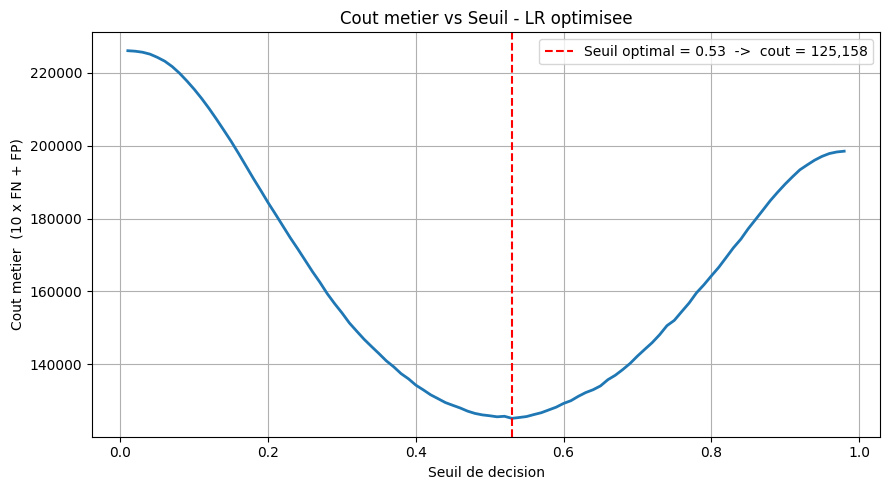

Run MLflow : LR_optimise enregistre.


In [18]:
with mlflow.start_run(run_name='LR_optimise'):
    mlflow.set_tag('model_type', 'optimise')
    mlflow.set_tags(_SPLIT_TAGS)
    mlflow.log_params(best_lr_params)

    print('=== Logistic Regression optimisee ===')
    logreg_opt_metrics, logreg_opt_proba = cv_sklearn(
        'LR optimisee',
        lambda: LogisticRegression(
            **best_lr_params, max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=1,
        ),
        X_train, y_train, needs_scaling=True,
    )
    log_metrics_mlflow(logreg_opt_metrics)

    # Evaluation sur le jeu de test (non vu pendant la CV)
    final_lr = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('lr',      LogisticRegression(
            **best_lr_params, max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=1,
        )),
    ])
    final_lr.fit(X_train, y_train)
    lr_test_proba = final_lr.predict_proba(X_test)[:, 1]
    auc_test_lr   = roc_auc_score(y_test, lr_test_proba)
    gap_lr        = round(logreg_opt_metrics['AUC moy'] - auc_test_lr, 4)
    mlflow.log_metric('auc_test',     round(auc_test_lr, 4))
    mlflow.log_metric('gap_oof_test', gap_lr)
    print(f'AUC OOF : {logreg_opt_metrics["AUC moy"]:.4f}  |  AUC Test : {auc_test_lr:.4f}  |  Gap : {gap_lr:.4f}')

    # Reentretainement sur tout le dataset pour la production
    final_lr.fit(X, y)
    mlflow.sklearn.log_model(
        final_lr, 'model',
        registered_model_name='LR_credit_scoring',
    )

    fig_thr_lr = plot_threshold_curve(y_train, logreg_opt_proba, 'LR optimisee')
    mlflow.log_figure(fig_thr_lr, 'threshold_curve.png')
    fig_thr_lr.savefig(FIGURES_DIR / 'threshold_lr_opt.png', dpi=150, bbox_inches='tight')
    plt.close(fig_thr_lr)

    print('Run MLflow : LR_optimise enregistre.')


### 4.4 CV finale - LightGBM optimise

=== LightGBM optimise ===
  Fold 1/5  AUC = 0.7872  (meilleure iteration = 332)
  Fold 2/5  AUC = 0.7860  (meilleure iteration = 384)
  Fold 3/5  AUC = 0.7876  (meilleure iteration = 451)
  Fold 4/5  AUC = 0.7898  (meilleure iteration = 355)
  Fold 5/5  AUC = 0.7869  (meilleure iteration = 338)
  -> OOF AUC = 0.7875 +/- 0.0013
AUC OOF : 0.7875  |  AUC Test : 0.7893  |  Gap : -0.0018


2026/05/30 15:15:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/30 15:15:00 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/30 15:15:17 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Successfully registered model 'LightGBM_credit_scoring'.
Created version '1' of model 'LightGBM_credit_scoring'.


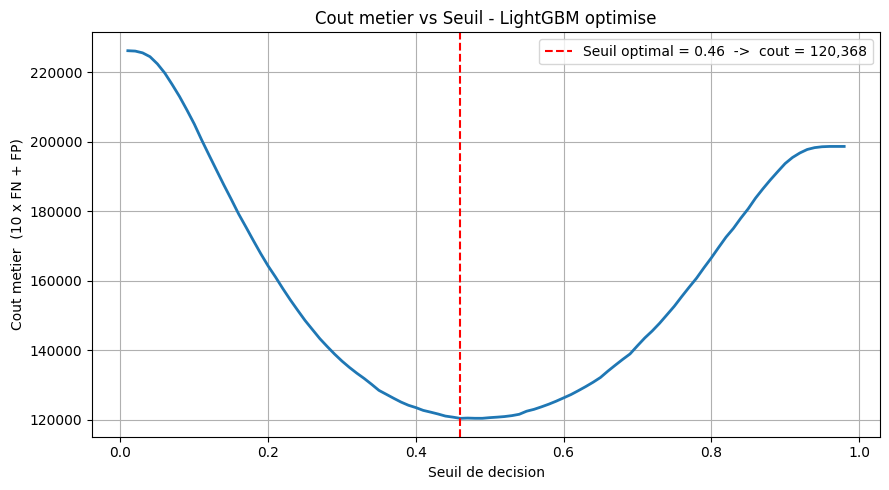

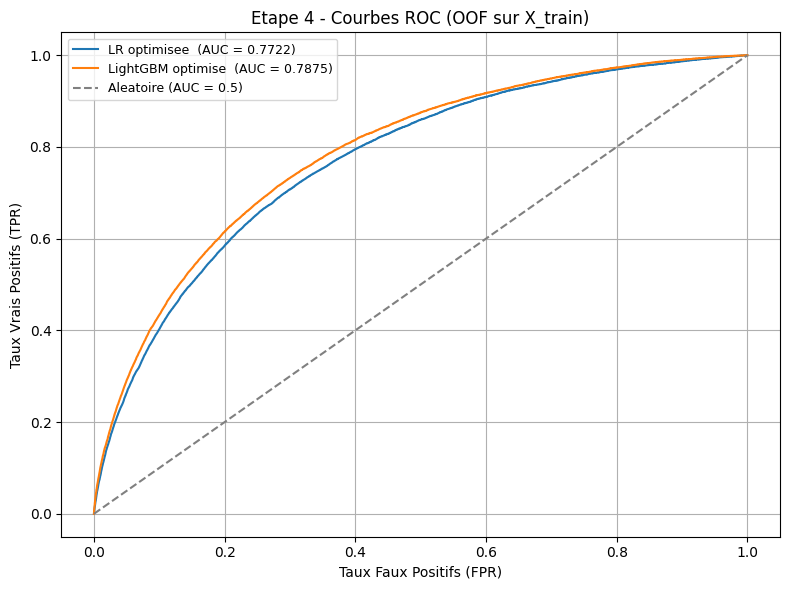

Run MLflow : LightGBM_optimise enregistre.


In [19]:
with mlflow.start_run(run_name='LightGBM_optimise'):
    mlflow.set_tag('model_type', 'optimise')
    mlflow.set_tags(_SPLIT_TAGS)
    _exclude = ('n_jobs', 'verbosity', 'objective', 'random_state')
    mlflow.log_params({k: v for k, v in LGBM_BEST_PARAMS.items() if k not in _exclude})

    print('=== LightGBM optimise ===')
    lgbm_opt_metrics, lgbm_opt_proba = cv_lgbm(
        'LightGBM optimise', LGBM_BEST_PARAMS, X_train, y_train
    )
    log_metrics_mlflow(lgbm_opt_metrics)

    # Evaluation sur le jeu de test (non vu pendant la CV)
    final_lgbm = LGBMClassifier(**LGBM_BEST_PARAMS)
    final_lgbm.fit(X_train, y_train)
    lgbm_test_proba = final_lgbm.predict_proba(X_test)[:, 1]
    auc_test_lgbm   = roc_auc_score(y_test, lgbm_test_proba)
    gap_lgbm        = round(lgbm_opt_metrics['AUC moy'] - auc_test_lgbm, 4)
    mlflow.log_metric('auc_test',     round(auc_test_lgbm, 4))
    mlflow.log_metric('gap_oof_test', gap_lgbm)
    print(f'AUC OOF : {lgbm_opt_metrics["AUC moy"]:.4f}  |  AUC Test : {auc_test_lgbm:.4f}  |  Gap : {gap_lgbm:.4f}')

    # Reentretainement sur tout le dataset pour la production
    final_lgbm.fit(X, y)
    mlflow.lightgbm.log_model(
        final_lgbm, 'model',
        registered_model_name='LightGBM_credit_scoring',
    )

    # Courbes loggees comme artefacts du run
    fig_thr_lgbm = plot_threshold_curve(y_train, lgbm_opt_proba, 'LightGBM optimise')
    mlflow.log_figure(fig_thr_lgbm, 'threshold_curve.png')
    fig_thr_lgbm.savefig(FIGURES_DIR / 'threshold_lgbm_opt.png', dpi=150, bbox_inches='tight')
    plt.close(fig_thr_lgbm)

    fig_roc_opt = plot_roc_curves(
        {'LR optimisee': logreg_opt_proba, 'LightGBM optimise': lgbm_opt_proba},
        y_train, title='Etape 4 - Courbes ROC (OOF sur X_train)',
    )
    mlflow.log_figure(fig_roc_opt, 'roc_curve_optimises.png')
    fig_roc_opt.savefig(FIGURES_DIR / 'roc_step4.png', dpi=150, bbox_inches='tight')
    plt.close(fig_roc_opt)

    print('Run MLflow : LightGBM_optimise enregistre.')


### Resultats finaux - Etapes 3 & 4

  Resultats finaux - tous les modeles


,AUC moy,AUC std,PR-AUC,Recall,Precision,F1,Seuil,Cout metier,FN,FP
Modele,,,,,,,,,,
Dummy,0.5000,0.0000,0.0807,0.0000,0.0000,0.0000,0.090000,198600,19860,0
Logistic Regression,0.7724,0.0023,0.2488,0.6883,0.1777,0.2825,0.510000,125151,6191,63241
LR optimisee,0.7722,0.0024,0.2493,0.6644,0.1840,0.2882,0.530000,125158,6665,58508
LightGBM baseline,0.7859,0.0010,0.2746,0.6899,0.1882,0.2958,0.490000,120670,6159,59080
LightGBM optimise,0.7875,0.0013,0.2777,0.7131,0.1826,0.2908,0.460000,120368,5697,63398


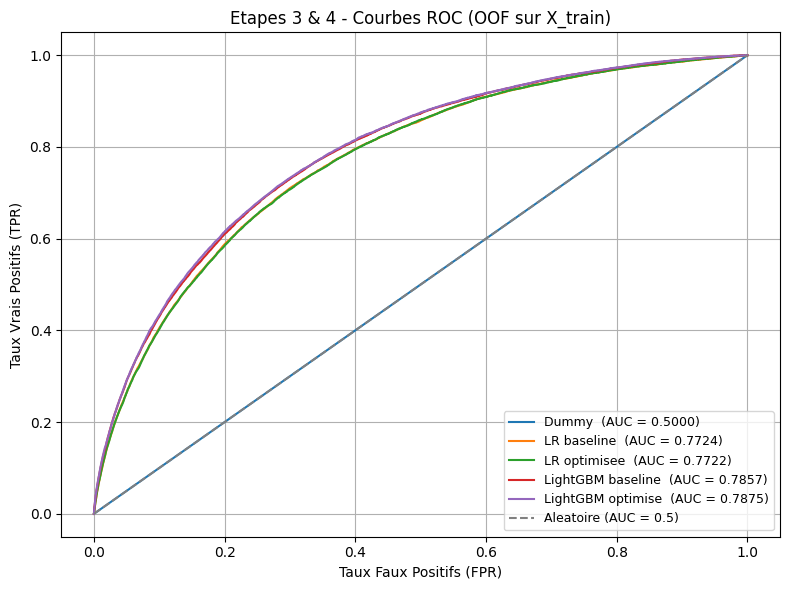

Figures sauvegardees dans reports/figures/


In [20]:
all_results = pd.DataFrame([
    dummy_metrics,
    logreg_metrics,
    logreg_opt_metrics,
    lgbm_metrics,
    lgbm_opt_metrics,
]).set_index('Modele')

display_results(all_results, 'Resultats finaux - tous les modeles')

fig_roc_all = plot_roc_curves(
    {
        'Dummy':              dummy_proba,
        'LR baseline':        logreg_proba,
        'LR optimisee':       logreg_opt_proba,
        'LightGBM baseline':  lgbm_proba,
        'LightGBM optimise':  lgbm_opt_proba,
    },
    y_train, title='Etapes 3 & 4 - Courbes ROC (OOF sur X_train)',
)
fig_roc_all.savefig(FIGURES_DIR / 'roc_all.png', dpi=150, bbox_inches='tight')
plt.close(fig_roc_all)
print('Figures sauvegardees dans reports/figures/')


---
## 5. Matrice de confusion — LightGBM optimise

Calculee sur le **jeu de test** (`X_test`, `y_test`) au **seuil optimal** trouve sur les predictions OOF — evaluation non biaisee sur des donnees jamais vues.

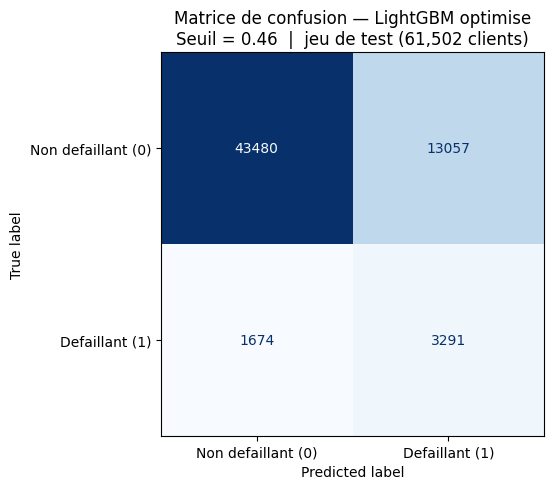


Seuil optimal (OOF) : 0.46
VP (True Pos.)      :    3,291  — defaillants detectes
FN (False Neg.)     :    1,674  — defaillants manques  [cout x10]
FP (False Pos.)     :   13,057  — bons clients refuses [cout x1]
VN (True Neg.)      :   43,480  — bons clients acceptes

Cout metier         : 29,797
Recall              : 0.6628
Precision           : 0.2013

Run MLflow : LightGBM_confusion_matrix enregistre.


In [21]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from src.config import FIGURES_DIR

# Seuil trouve sur les predictions OOF (X_train), applique au jeu de test
thresh_lgbm     = lgbm_opt_metrics['Seuil']
y_pred_lgbm_tst = (lgbm_test_proba >= thresh_lgbm).astype(int)

cm = confusion_matrix(y_test, y_pred_lgbm_tst)
tn, fp, fn, tp = cm.ravel()

# Figure
fig_cm, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non defaillant (0)', 'Defaillant (1)'],
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(
    f'Matrice de confusion — LightGBM optimise\n'
    f'Seuil = {thresh_lgbm:.2f}  |  jeu de test ({len(y_test):,} clients)',
    fontsize=12,
)
plt.tight_layout()
plt.show()

# Resume chiffre
print(f'\nSeuil optimal (OOF) : {thresh_lgbm:.2f}')
print(f'VP (True Pos.)      : {tp:>8,}  — defaillants detectes')
print(f'FN (False Neg.)     : {fn:>8,}  — defaillants manques  [cout x10]')
print(f'FP (False Pos.)     : {fp:>8,}  — bons clients refuses [cout x1]')
print(f'VN (True Neg.)      : {tn:>8,}  — bons clients acceptes')
print(f'\nCout metier         : {10*fn + fp:,}')
print(f'Recall              : {tp/(tp+fn):.4f}')
print(f'Precision           : {tp/(tp+fp):.4f}')

# Tracking MLflow
with mlflow.start_run(run_name='LightGBM_confusion_matrix'):
    mlflow.set_tag('model_type', 'evaluation')
    mlflow.set_tags(_SPLIT_TAGS)
    mlflow.log_param('threshold', thresh_lgbm)
    mlflow.log_param('eval_set',  'test')
    mlflow.log_metrics({
        'tp': int(tp), 'tn': int(tn),
        'fp': int(fp), 'fn': int(fn),
        'cout_metier': int(10*fn + fp),
        'auc_test':    round(auc_test_lgbm, 4),
    })
    mlflow.log_figure(fig_cm, 'confusion_matrix.png')
    fig_cm.savefig(FIGURES_DIR / 'confusion_matrix_lgbm.png', dpi=150, bbox_inches='tight')
    plt.close(fig_cm)
    print('\nRun MLflow : LightGBM_confusion_matrix enregistre.')


## 6. Sauvegarde locale des modeles (.pkl)

In [22]:
import joblib

# Sauvegarde locale en complement du stockage MLflow
lr_path   = MODELS_DIR / 'lr_optimized.pkl'
lgbm_path = MODELS_DIR / 'lgbm_optimized.pkl'

joblib.dump(final_lr,   lr_path)
joblib.dump(final_lgbm, lgbm_path)

print(f'LR   : {lr_path}')
print(f'LGBM : {lgbm_path}')


LR   : C:\Users\fkhellad\Formation_IA\Projet6_mission\models\lr_optimized.pkl
LGBM : C:\Users\fkhellad\Formation_IA\Projet6_mission\models\lgbm_optimized.pkl


---
## 7. Feature Importance — SHAP

SHAP (SHapley Additive exPlanations) quantifie la contribution de chaque feature aux predictions du modele LightGBM final.

Les colonnes issues du one-hot encoding sont **regroupees** par variable d'origine (via `original_categorical_columns.csv`) pour ne pas diluer leur importance globale.

Calcul sur un echantillon de 5 000 lignes pour la rapidite.

In [23]:
import shap
from src.config import FIGURES_DIR, PROCESSED_DIR

# Colonnes categorielles avant encodage — genere par feature_engineering.py
_cat_df = pd.read_csv(PROCESSED_DIR / 'original_categorical_columns.csv')
original_cat_cols = _cat_df['original_categorical_column'].unique().tolist()

# Mapping : variable d'origine -> colonnes one-hot encodees dans X
group_mapping = {}
for _col in original_cat_cols:
    _matches = [c for c in X_train.columns if c.startswith(_col + '_')]
    if _matches:
        group_mapping[_col] = _matches

print(f'{len(group_mapping)} variables categorielless avec one-hot dans X.')


13 variables categorielless avec one-hot dans X.


In [24]:
# Echantillon sur X_train uniquement — le jeu de test reste reserve a l'evaluation
SHAP_SAMPLE = 5_000
X_shap = X_train.sample(SHAP_SAMPLE, random_state=RANDOM_STATE)
y_shap = y_train.loc[X_shap.index]

# TreeExplainer : optimise pour les modeles a base d'arbres
explainer   = shap.TreeExplainer(final_lgbm)
shap_values = explainer.shap_values(X_shap)

# LightGBM binaire peut retourner une liste [classe 0, classe 1]
if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap_df = pd.DataFrame(shap_values, columns=X_shap.columns)
print(f'shap_df : {shap_df.shape}  (echantillon : {SHAP_SAMPLE} lignes)')


shap_df : (5000, 552)  (echantillon : 5000 lignes)


In [25]:
# ── Regroupement one-hot -> variable d'origine ────────────────────────────
abs_shap_df  = shap_df.abs()
one_hot_cols = set()
grouped_series = []

for _col, _encoded in group_mapping.items():
    _present = list(set(_encoded) & set(abs_shap_df.columns))
    if _present:
        one_hot_cols.update(_present)
        # Somme des contributions de toutes les modalites d'une meme variable
        grouped_series.append(
            abs_shap_df[_present].sum(axis=1).rename(_col)
        )

# Variables continues : conservees telles quelles
_non_ohe = [c for c in abs_shap_df.columns if c not in one_hot_cols]
grouped_series.append(abs_shap_df[_non_ohe])

grouped_shap_df = pd.concat(grouped_series, axis=1)

# Importance globale = moyenne des |valeurs SHAP| par feature
shap_importance = (
    grouped_shap_df.mean()
    .sort_values(ascending=False)
    .reset_index()
)
shap_importance.columns = ['feature', 'mean_abs_shap']
display(shap_importance.head(20))


,feature,mean_abs_shap
0,EXT_SOURCE_MEAN,0.396168
1,AMT_ANNUITY,0.141846
2,PAYMENT_RATE,0.138998
3,CODE_GENDER,0.117691
4,DAYS_EMPLOYED,0.111510
5,ACTIVE_DEBT_PERCENTAGE_MAX,0.106376
6,AMT_GOODS_PRICE,0.098101
7,NAME_EDUCATION_TYPE,0.087362
8,EXT_SOURCE_1,0.085106
9,OWN_CAR_AGE,0.083872


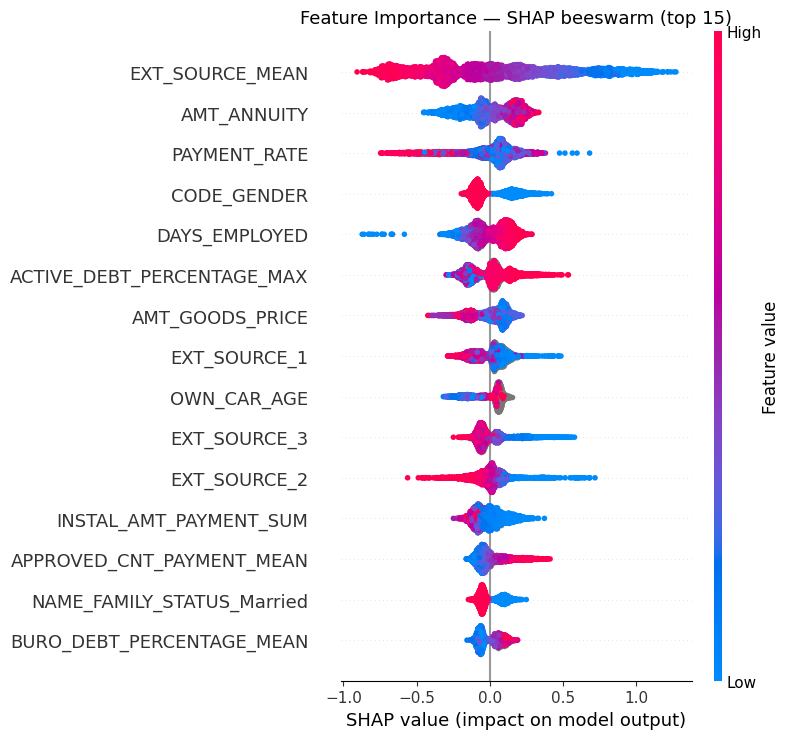

In [26]:
# ── Summary plot (beeswarm) — features brutes, top 15 ─────────────────────
# show=False : laisse matplotlib geree la figure sans l'afficher immediatement
shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
fig_shap_beeswarm = plt.gcf()
plt.title('Feature Importance — SHAP beeswarm (top 15)', fontsize=13)
plt.tight_layout()
plt.show()


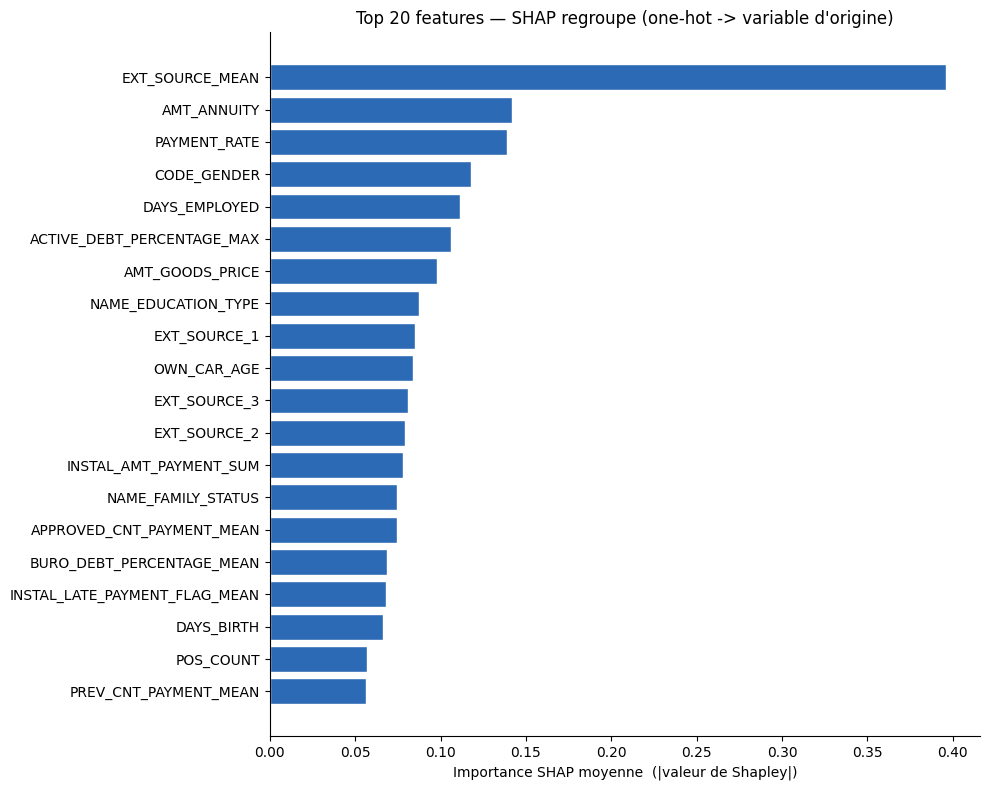

In [27]:
# ── Bar chart — top 20 features regroupees ────────────────────────────────
_top20 = shap_importance.head(20)
fig_shap_bar, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    _top20['feature'][::-1].values,
    _top20['mean_abs_shap'][::-1].values,
    color='#2D6AB5', edgecolor='white',
)
ax.set_xlabel('Importance SHAP moyenne  (|valeur de Shapley|)')
ax.set_title('Top 20 features — SHAP regroupe (one-hot -> variable d\'origine)')
ax.spines[['top', 'right']].set_visible(False)
fig_shap_bar.tight_layout()
plt.show()


### 6.6 SHAP local — Analyse individuelle

Waterfall plot pour **un client non defaillant** (TARGET=0) et **un client defaillant** (TARGET=1).

Chaque barre montre la contribution d'une feature a l'ecart entre la prediction individuelle et la valeur de base E[f(X)].

Client non defaillant selectionne — proba predite : 0.0077  (TARGET = 0)
Client defaillant selectionne — proba predite : 0.9619  (TARGET = 1)


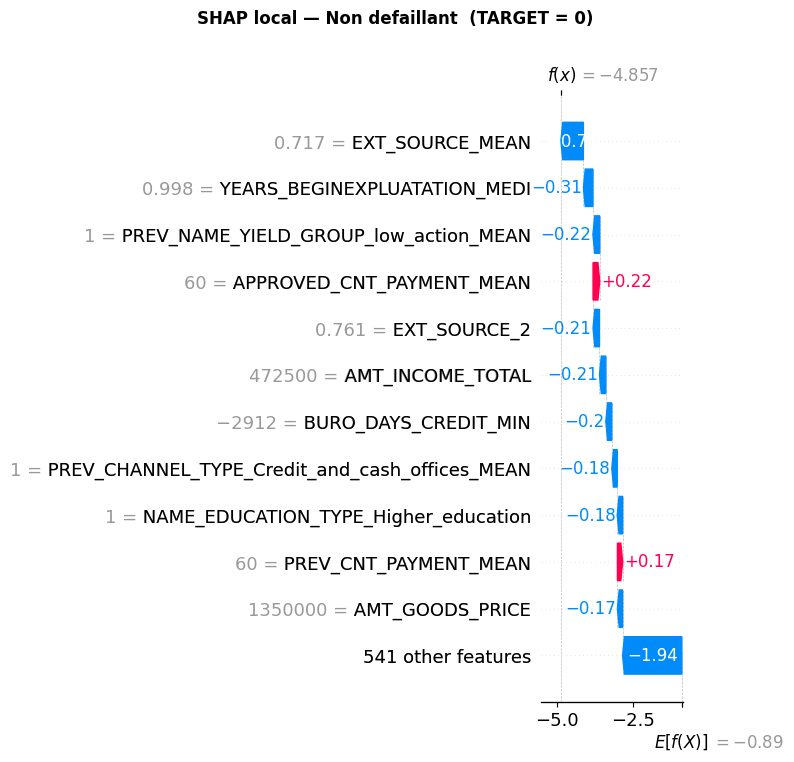

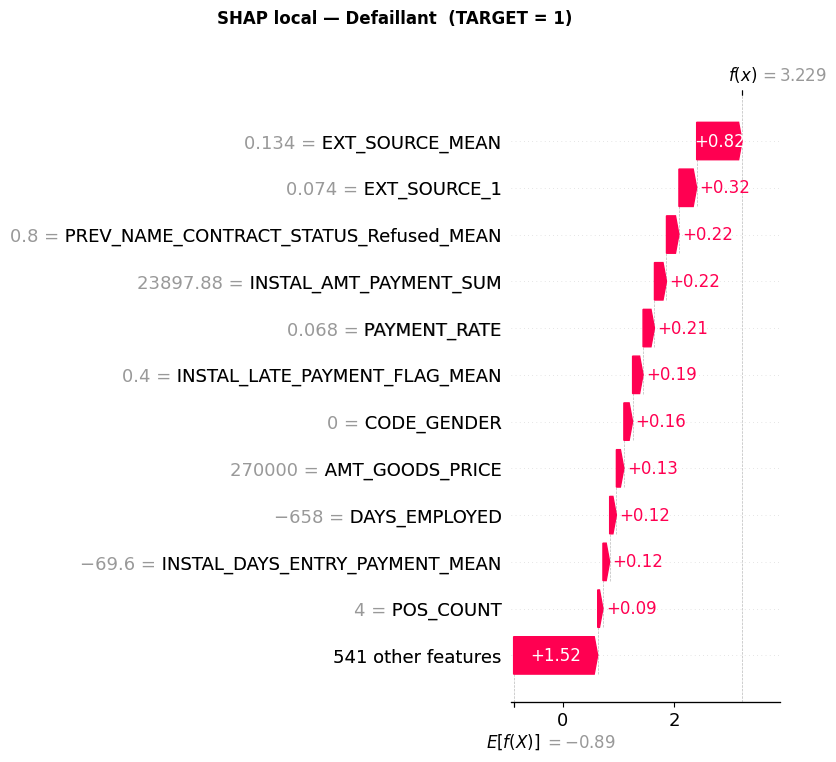

In [28]:
# shap.Explanation — objet requis pour les waterfall plots
shap_explanation = explainer(X_shap)

# LightGBM binaire peut retourner shape (n, features, 2) -> classe positive
if len(shap_explanation.shape) == 3:
    shap_explanation = shap_explanation[:, :, 1]

# Probabilites predites sur l'echantillon SHAP
y_proba_shap = final_lgbm.predict_proba(X_shap)[:, 1]

# Client non defaillant : TARGET=0 ET probabilite predite < 20%
_mask_non_def = (y_shap.values == 0) & (y_proba_shap < 0.20)
if _mask_non_def.sum() == 0:
    print('Aucun client TARGET=0 avec proba < 20% — seuil releve a 40%')
    _mask_non_def = (y_shap.values == 0) & (y_proba_shap < 0.40)
_candidates_nd = np.where(_mask_non_def)[0]
# Parmi les candidats, on prend celui avec la probabilite la plus basse
idx_non_def = int(_candidates_nd[np.argmin(y_proba_shap[_candidates_nd])])
print(f'Client non defaillant selectionne — proba predite : {y_proba_shap[idx_non_def]:.4f}  (TARGET = {y_shap.iloc[idx_non_def]})')

# Client defaillant : TARGET=1 ET probabilite predite > 53%
_mask_def = (y_shap.values == 1) & (y_proba_shap > 0.53)
if _mask_def.sum() == 0:
    print('Aucun client TARGET=1 avec proba > 53% — seuil abaisse a 30%')
    _mask_def = (y_shap.values == 1) & (y_proba_shap > 0.30)
_candidates = np.where(_mask_def)[0]
# Parmi les candidats, on prend celui avec la probabilite la plus elevee
idx_def = int(_candidates[np.argmax(y_proba_shap[_candidates])])
print(f'Client defaillant selectionne — proba predite : {y_proba_shap[idx_def]:.4f}  (TARGET = {y_shap.iloc[idx_def]})')

fig_wf_non_def = None
fig_wf_def     = None

for label, idx, cible in [
    ('Non defaillant', idx_non_def, 0),
    ('Defaillant',     idx_def,     1),
]:
    shap.plots.waterfall(shap_explanation[idx], max_display=12, show=False)
    fig = plt.gcf()
    plt.suptitle(
        f'SHAP local — {label}  (TARGET = {cible})',
        fontsize=12, fontweight='bold', y=1.01,
    )
    plt.tight_layout()
    plt.show()
    if cible == 0:
        fig_wf_non_def = fig
    else:
        fig_wf_def = fig


In [29]:
# ── Tracking MLflow ───────────────────────────────────────────────────────
with mlflow.start_run(run_name='LightGBM_SHAP'):
    mlflow.set_tag('model_type',  'interpretabilite')
    mlflow.set_tags(_SPLIT_TAGS)
    mlflow.log_param('n_shap_samples', SHAP_SAMPLE)
    mlflow.log_param('shap_explainer', 'TreeExplainer')
    mlflow.log_param('n_features_top', 20)

    # Figures globales
    mlflow.log_figure(fig_shap_beeswarm, 'shap_beeswarm.png')
    mlflow.log_figure(fig_shap_bar,      'shap_importance_grouped.png')

    # Figures locales
    mlflow.log_figure(fig_wf_non_def, 'shap_waterfall_non_defaillant.png')
    mlflow.log_figure(fig_wf_def,     'shap_waterfall_defaillant.png')

    # Top 20 features en JSON — comparable entre plusieurs runs
    _top20_dict = (
        shap_importance.head(20)
        .set_index('feature')['mean_abs_shap']
        .round(6)
        .to_dict()
    )
    mlflow.log_dict(_top20_dict, 'shap_top20_features.json')

    # Sauvegarde dans reports/figures/ pour la presentation
    fig_shap_beeswarm.savefig(
        FIGURES_DIR / 'shap_beeswarm.png', dpi=150, bbox_inches='tight'
    )
    fig_shap_bar.savefig(
        FIGURES_DIR / 'shap_importance.png', dpi=150, bbox_inches='tight'
    )
    fig_wf_non_def.savefig(
        FIGURES_DIR / 'shap_waterfall_non_defaillant.png', dpi=150, bbox_inches='tight'
    )
    fig_wf_def.savefig(
        FIGURES_DIR / 'shap_waterfall_defaillant.png', dpi=150, bbox_inches='tight'
    )
    plt.close('all')

    print('Run MLflow : LightGBM_SHAP enregistre.')
    print('Artefacts  : beeswarm | importance | 2 waterfall plots | top20 JSON')
    print(f'Figures sauvegardees dans {FIGURES_DIR}')


Run MLflow : LightGBM_SHAP enregistre.
Artefacts  : beeswarm | importance | 2 waterfall plots | top20 JSON
Figures sauvegardees dans C:\Users\fkhellad\Formation_IA\Projet6_mission\reports\figures
